In [1]:
import json
import re
import pandas as pd

pd.set_option('display.float_format', '{:.3f}'.format)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

In [2]:
RESULTS_FILE = 'results/ictir_eval.jsonl'

with open(RESULTS_FILE) as f:
    rows = [json.loads(l) for l in f]

df = pd.DataFrame(rows)
print(f'{len(df)} rows, {df["model"].nunique()} models, {df["dataset"].nunique()} datasets')

265 rows, 9 models, 16 datasets


In [3]:
def parse_model(path):
    name = path.removeprefix('output/modernbert_').removesuffix('/final')
    stage = 'kd' if 'kd' in name.split('_') else 'contrastive'
    if 'colbert' in name:
        model_type = 'colbert'
    elif 'multi' in name:
        model_type = 'xtr_multi'
    else:
        m = re.search(r'k(\d+)', name)
        model_type = f'xtr_k{m.group(1)}'
    return model_type, stage

def short_dataset(d):
    if "beir" in d:
        dataset =  d.split('/')[-2] if (any(s in d for s in ['test', 'v2', 'dev'])) else d.rsplit('/', 1)[-1]
        return f'B_{dataset}'
    elif "lotte" in d:
        #lotte/{split}/dev/search
        # return l_{split}
        dataset = d.split("/")[-3]
        return f'L_{dataset}'

df[['model_type', 'stage']] = df['model'].apply(lambda m: pd.Series(parse_model(m)))
df['dataset_short'] = df['dataset'].apply(short_dataset)
df['benchmark'] = df['dataset'].apply(lambda d: 'beir' if 'beir' in d else 'lotte')

MODEL_ORDER = ['colbert', 'xtr_k512', 'xtr_k256', 'xtr_k128', 'xtr_multi']
STAGE_ORDER = ['kd', 'contrastive']
INDEX_ORDER = ['warp', 'plaid']

df['model_type'] = pd.Categorical(df['model_type'], categories=MODEL_ORDER, ordered=True)
df['stage'] = pd.Categorical(df['stage'], categories=STAGE_ORDER, ordered=True)
df['index_type'] = pd.Categorical(df['index_type'], categories=INDEX_ORDER, ordered=True)

In [4]:
metrics = ['ndcg@10', 'recall@100', 'mrr@10','hit_rate@5', 'qps', 'build_time_s', 'index_size_mb']
pt = df.query("model_type != 'xtr_k128'").pivot_table(
    index=['index_type', 'model_type', 'stage'],
    columns='dataset_short',
    values=metrics,
    sort=False,
).sort_index()

# Add avg columns in the order of metrics
for metric in metrics:
    pt[(metric, 'avg')] = pt[metric].mean(axis=1)

# Order the columns so metrics are in the given order for each dataset/avg
# This creates a MultiIndex with metrics as the first level ordered as in `metrics`
ordered_cols = []
# For each metric, gather all (metric, dataset) columns in order, plus the avg at the end
datasets = [c for c in pt.columns.get_level_values(1).unique() if c != 'avg']
for metric in metrics:
    for d in datasets:
        if (metric, d) in pt.columns:
            ordered_cols.append((metric, d))
    if (metric, 'avg') in pt.columns:
        ordered_cols.append((metric, 'avg'))

pt = pt[ordered_cols]

# Scale IR metrics to percentage points
for metric in ['ndcg@10', 'recall@100', 'mrr@10', 'hit_rate@5']:
    pt[metric] = pt[metric] * 100
pt.style.format('{:.1f}')


## Results Table

In [5]:
tbl = df.query("model_type != 'xtr_k128'").copy()

# Metric selection by benchmark:
# - BEIR datasets: ndcg@10
# - MS MARCO: mrr@10
# - LoTTE datasets: hit_rate@5
tbl['selected_score'] = tbl['ndcg@10']
msmarco_mask = tbl['dataset_short'].str.contains('msmarco', case=False, na=False)
lotte_mask = tbl['benchmark'].eq('lotte')

tbl.loc[msmarco_mask, 'selected_score'] = tbl.loc[msmarco_mask, 'mrr@10']
tbl.loc[lotte_mask, 'selected_score'] = tbl.loc[lotte_mask, 'hit_rate@5']

pt_mixed_metric = tbl.pivot_table(
    index=['index_type', 'stage', 'model_type'],
    columns='dataset_short',
    values='selected_score',
    sort=False,
).sort_index()

# Move MS MARCO to the first column.
msmarco_cols = [c for c in pt_mixed_metric.columns if 'msmarco' in str(c).lower()]
other_cols = [c for c in pt_mixed_metric.columns if c not in msmarco_cols]
pt_mixed_metric = pt_mixed_metric[msmarco_cols + other_cols]

# Show scores in percentage points.
pt_mixed_metric = pt_mixed_metric * 100
pt_mixed_metric.style.format('{:.1f}')

print(pt_mixed_metric.to_latex())


\begin{tabular}{lllrrrrrrrrrrrrrrrr}
\toprule
 &  & dataset_short & B_msmarco & B_nfcorpus & B_scifact & B_scidocs & B_trec-covid & B_fiqa & L_lifestyle & L_writing & L_recreation & L_technology & L_science & L_pooled & B_arguana & B_webis-touche2020 & B_quora & B_nq \\
index_type & stage & model_type &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  \\
\midrule
\multirow[t]{8}{*}{warp} & \multirow[t]{4}{*}{kd} & colbert & 31.180000 & 33.580000 & 52.450000 & 12.890000 & 72.360000 & 12.880000 & 83.210000 & 81.790000 & 68.400000 & 62.750000 & 55.590000 & 69.940000 & 17.000000 & 30.530000 & 81.590000 & 48.180000 \\
 &  & xtr_k512 & 33.670000 & 34.240000 & 70.510000 & 15.780000 & 74.310000 & 35.720000 & 83.360000 & 80.490000 & 71.540000 & 64.260000 & 58.020000 & 71.830000 & 29.700000 & 28.720000 & 84.790000 & 51.720000 \\
 &  & xtr_k256 & 33.760000 & 32.990000 & 71.250000 & 15.830000 & 78.070000 & 35.890000 & 84.420000 & 81.140000 & 69.910000 & 65.600000 & 60.290000 & 70.640000 & 32.770000 &

In [6]:
# Compute delta between 'kd' and 'contrastive' for each (index_type, model_type)
# The resulting pt_delta has the same columns as pt, but the index is (index_type, model_type)
pt_kd = pt.xs('kd', level='stage')
pt_contrastive = pt.xs('contrastive', level='stage')
pt_delta = pt_kd - pt_contrastive
pt_delta.index.names = ['index_type', 'model_type']

# Optionally format the output (as before)
pt_delta.style.format('{:.1f}')

In [7]:
# Compute delta between 'plaid' and 'warp' for each (model_type, training_stage)
# The resulting pt_delta has the same columns as pt, but the index is (model_type, training_stage)
pt_plaid = pt.xs('plaid', level='index_type')
pt_warp = pt.xs('warp', level='index_type')
pt_delta = pt_plaid - pt_warp
pt_delta.index.names = ['model_type', 'training_stage']

# Optionally format the output (as before)
pt_delta.style.format('{:.1f}')

In [8]:
# Compute delta between 'plaid' and 'warp' for each (model_type, training_stage)
# using relativized metrics (normalized to max value per dataset)

pt_plaid = pt.xs('plaid', level='index_type')
pt_warp = pt.xs('warp', level='index_type')

# Normalize each metric to its max value per dataset (column-wise)
# For each column (metric, dataset), divide by the max across all rows
pt_plaid_rel = pt_plaid.copy()
pt_warp_rel = pt_warp.copy()

for col in pt_plaid.columns:
    max_val = max(pt_plaid[col].max(), pt_warp[col].max())
    if max_val > 0:  # Avoid division by zero
        pt_plaid_rel[col] = pt_plaid[col] / max_val * 100
        pt_warp_rel[col] = pt_warp[col] / max_val * 100

# Compute delta on relativized metrics
pt_delta = pt_plaid_rel - pt_warp_rel
pt_delta.index.names = ['model_type', 'training_stage']

# Optionally format the output (as before)
pt_delta.style.format('{:.1f}')

In [190]:
# Pivot table: for each dataset, average qps for each index_type (warp, plaid), averaged over models and stage (contrastive, kd)

# First, pick out only qps rows (ignore IR metrics)
qps_pt = df.pivot_table(
    index=['index_type', 'dataset_short', 'model_type', 'stage'],
    values='qps',
    aggfunc='mean'
)

# Only keep warp and plaid, and order the index_types
qps_pt = qps_pt.loc[qps_pt.index.get_level_values('index_type').isin(['warp', 'plaid'])]
qps_pt = qps_pt.reorder_levels(['dataset_short', 'index_type', 'model_type', 'stage'])
qps_pt = qps_pt.sort_index()

# Now average over stage (kd vs contrastive) in addition to models
qps_summary = (
    qps_pt.groupby(['dataset_short', 'index_type', 'model_type'])
    .mean(numeric_only=True)  # average over 'stage' and any other present level
    .unstack(level='index_type')
    .round(1)
)

# Order as plaid, warp, speedup (warp/plaid)
plaid = qps_summary['qps', 'plaid']
warp = qps_summary['qps', 'warp']
speedup = (warp / plaid).rename('speedup')
qps_ordered = (
    pd.concat([plaid.rename('plaid'), warp.rename('warp'), speedup], axis=1)
)

# Drop any rows with NaN values (e.g., ColBERT PLAID on msmarco)
qps_ordered = qps_ordered.dropna()

from scipy.stats.mstats import gmean

# Overall geometric mean speedup
geomean_speedup = gmean(qps_ordered['speedup'])
print(f"Geometric mean speedup (overall): {geomean_speedup:.1f}")

# Geometric mean speedup for ColBERT models
colbert_speedups = qps_ordered.loc[qps_ordered.index.get_level_values('model_type') == 'colbert', 'speedup']
geomean_speedup_colbert = gmean(colbert_speedups)
print(f"Geometric mean speedup (ColBERT): {geomean_speedup_colbert:.1f}")

# Geometric mean speedup for XTR models
xtr_models = ['xtr_k256', 'xtr_k512', 'xtr_multi']
xtr_speedups = qps_ordered.loc[qps_ordered.index.get_level_values('model_type').isin(xtr_models), 'speedup']
geomean_speedup_xtr = gmean(xtr_speedups)
print(f"Geometric mean speedup (XTR): {geomean_speedup_xtr:.1f}")

qps_ordered.style.format('{:.1f}')

Geometric mean speedup (overall): 16.1
Geometric mean speedup (ColBERT): 29.5
Geometric mean speedup (XTR): 15.1


## Bar Plots

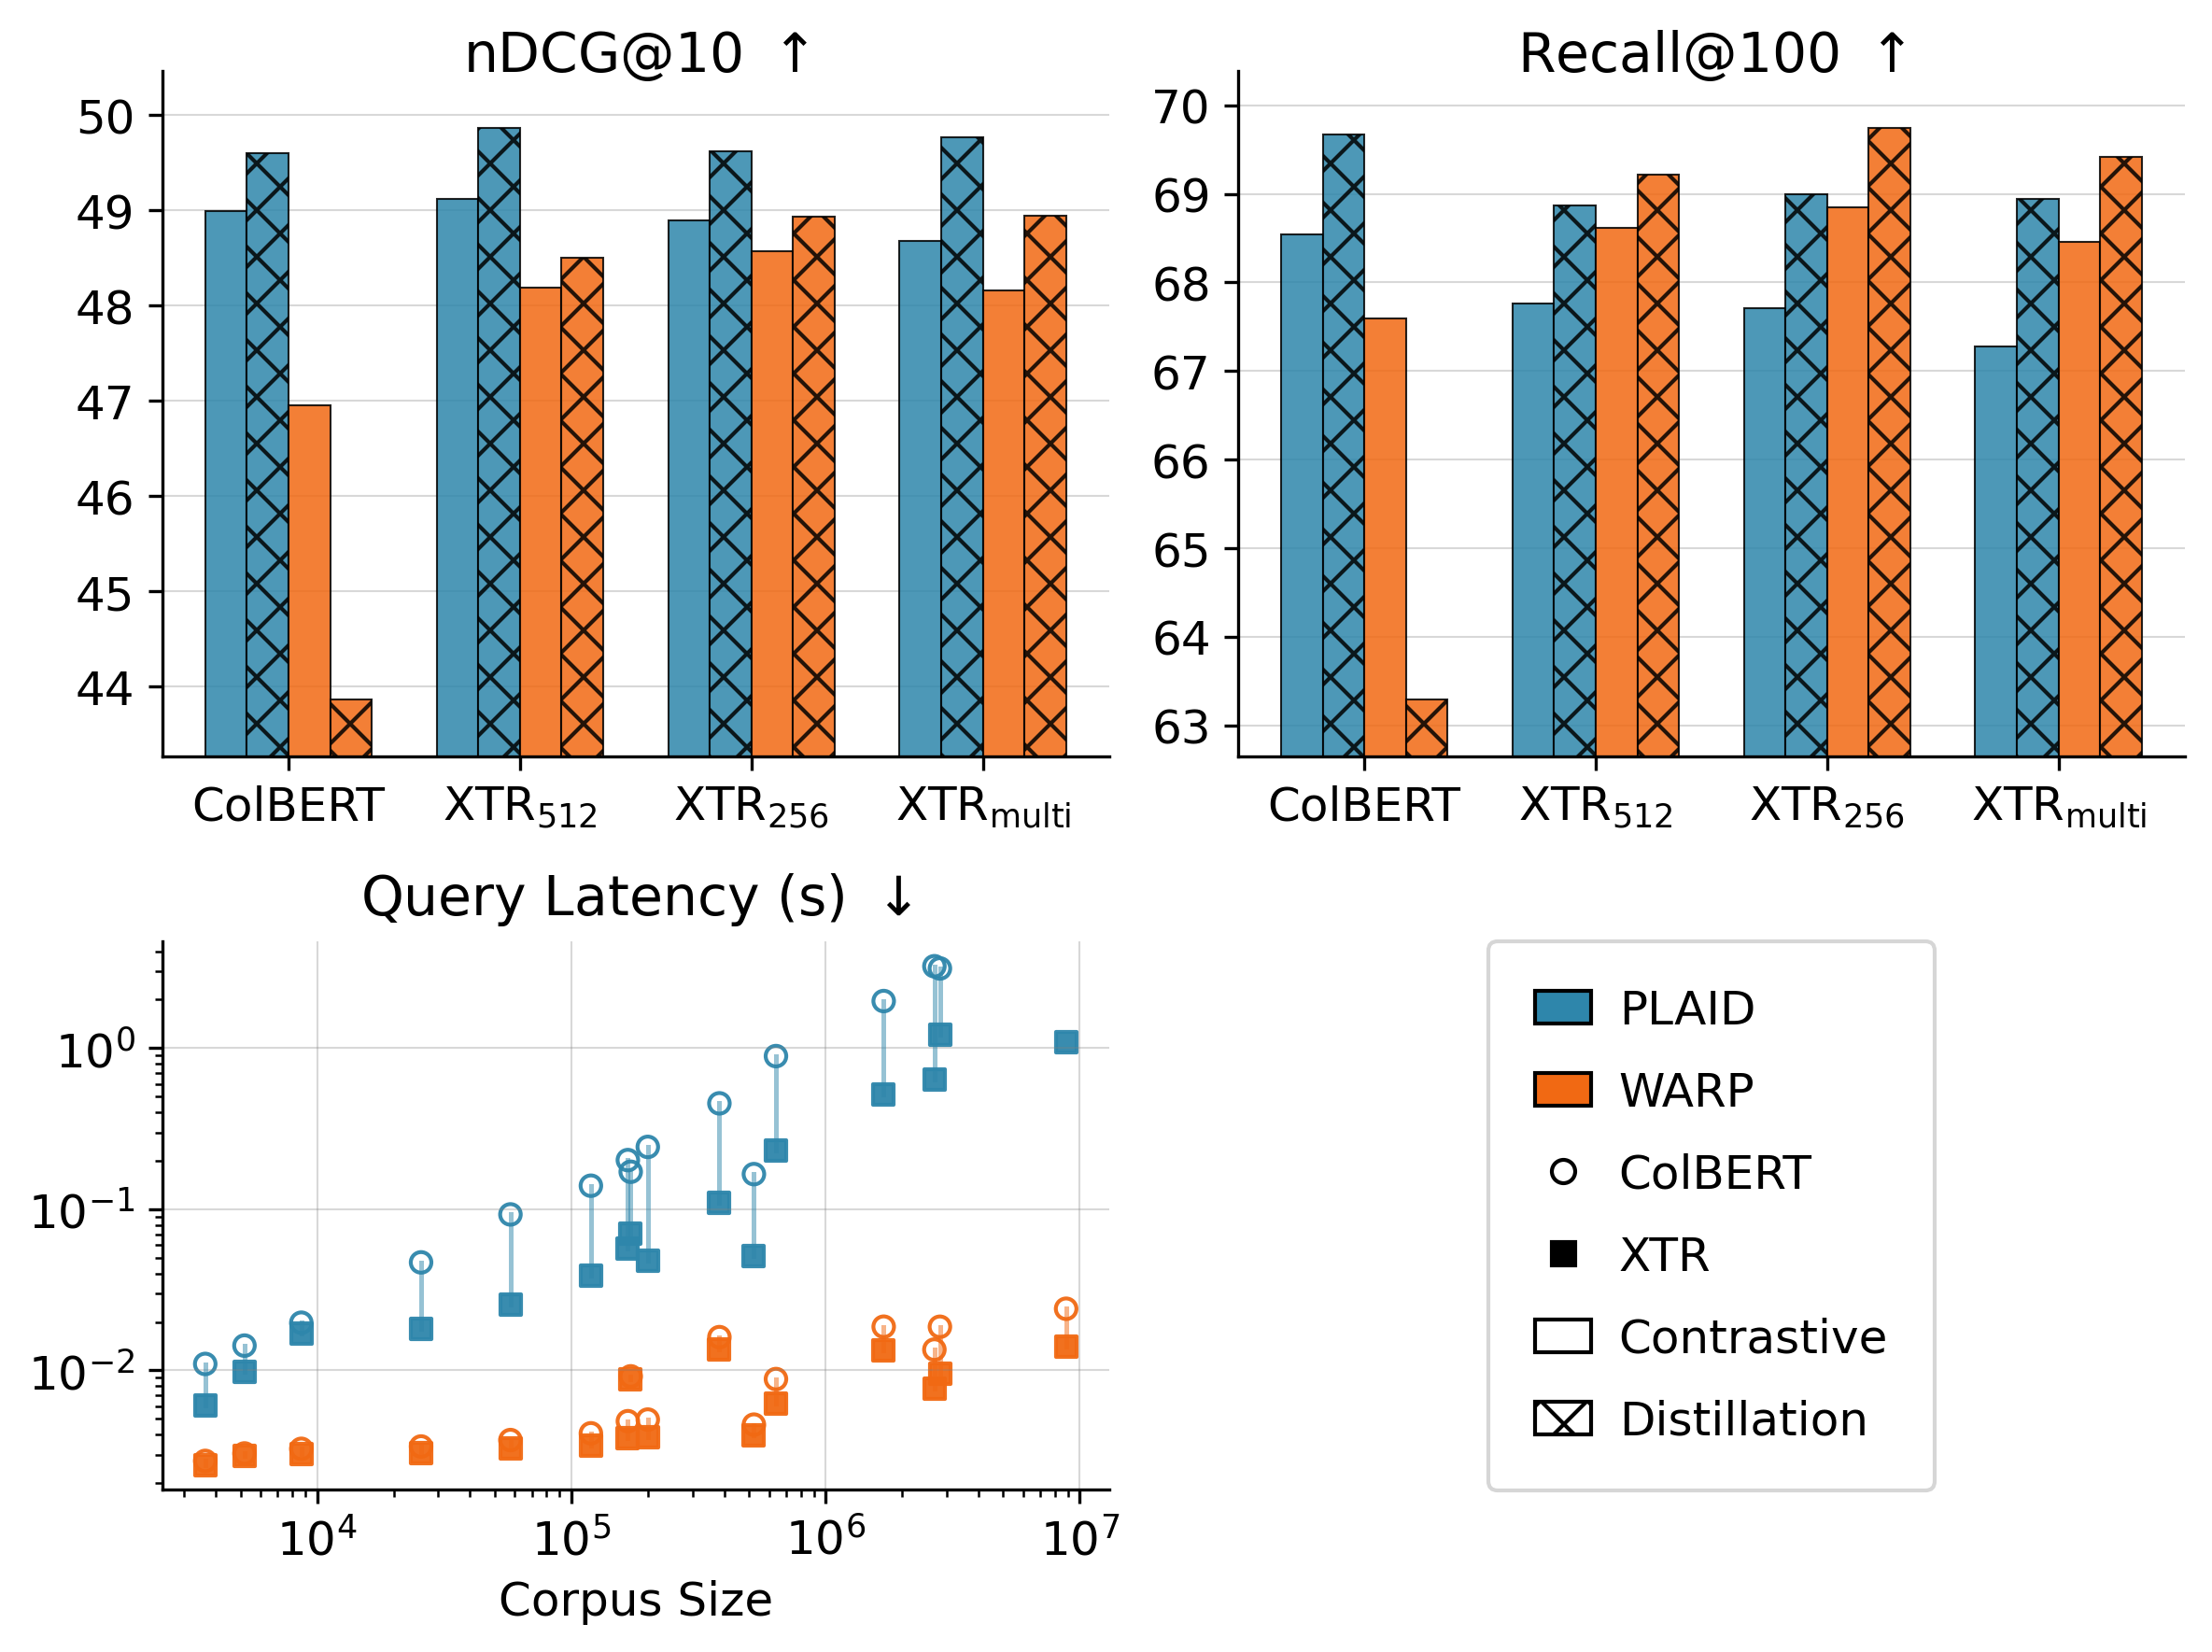

In [191]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib.ticker import MultipleLocator


# Desired metric display names and order (bar plots)
metrics_to_plot = [
    ('ndcg@10', r'nDCG@10 $\uparrow$'),
    ('recall@100', r'Recall@100 $\uparrow$'),
]

# Model mapping: code string -> latex pretty label
model_map = {
    'colbert': r'ColBERT',
    'xtr_k128': r'XTR$_{128}$',
    'xtr_k256': r'XTR$_{256}$',
    'xtr_k512': r'XTR$_{512}$',
    'xtr_multi': r'XTR$_{\mathrm{multi}}$',
}

# Build ordered list of (model_code, pretty_label)
model_types = [m for m in MODEL_ORDER if m in pt.index.get_level_values('model_type').unique()]
model_labels = [model_map[m] for m in model_types]

index_types = list(sorted([i for i in INDEX_ORDER if i in pt.index.get_level_values('index_type').unique()]))
stages = ['contrastive', 'kd']

# Toggle to normalize values relative to max per metric
NORMALIZE_TO_MAX = False  # Set to False for absolute values
# Toggle the 4th panel (query latency paired plot)
SHOW_SCATTER_QUADRANT = True
# Toggle top/right spine visibility across all axes
REMOVE_TOP_RIGHT_SPINES = True
# Lower title baseline (smaller -> closer to plot area)
TITLE_Y = 1.0

x = np.arange(len(model_types))
width = 0.18  # thinner bars since there will be 4 per group

# 2x2 grid: 2 bar plots, legend panel, and paired latency panel.
# Make bottom row 2/3 the height of the top row.
fig, axes = plt.subplots(
    2,
    2,
    figsize=(8, 6),
    sharey=False,
    dpi=300,
    gridspec_kw={'height_ratios': [5, 4]},
)
axes = axes.flatten()

if REMOVE_TOP_RIGHT_SPINES:
    for ax in axes:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

colors = {'plaid': '#2E86AB', 'warp': '#f16913'}
hatches = {'contrastive': '', 'kd': 'xx'}

for metric_idx, (metric, metric_label) in enumerate(metrics_to_plot):
    ax = axes[metric_idx]
    all_vals = []
    # Collect all values for this metric to find the max (excluding msmarco)
    metric_max = None
    if NORMALIZE_TO_MAX:
        all_metric_vals = []
        for idx_type in index_types:
            for stage in stages:
                for m in model_types:
                    if (idx_type, m, stage) in pt.index:
                        row = pt.loc[(idx_type, m, stage), metric]
                        for dataset_col in row.index:
                            if dataset_col != 'avg' and 'msmarco' not in str(dataset_col).lower():
                                val = row[dataset_col]
                                if not np.isnan(val):
                                    all_metric_vals.append(val)
        if len(all_metric_vals) > 0:
            metric_max = np.max(all_metric_vals)
    for i, idx_type in enumerate(index_types):
        for j, stage in enumerate(stages):
            # Compute left offset for each bar in a group (4 bars per group)
            pos_offset = (i * len(stages) + j - 1.5) * width
            vals = []
            for m in model_types:
                if (idx_type, m, stage) in pt.index:
                    row = pt.loc[(idx_type, m, stage), metric]
                    dataset_vals = []
                    for dataset_col in row.index:
                        if dataset_col != 'avg' and 'msmarco' not in str(dataset_col).lower():
                            val = row[dataset_col]
                            if not np.isnan(val):
                                dataset_vals.append(val)
                    if len(dataset_vals) > 0:
                        val = np.mean(dataset_vals)
                        if NORMALIZE_TO_MAX and metric_max is not None and metric_max > 0:
                            val = val / metric_max
                        vals.append(val)
                    else:
                        vals.append(np.nan)
                else:
                    vals.append(np.nan)
            all_vals.append(np.array(vals))
            bars = ax.bar(
                x + pos_offset,
                vals,
                width,
                label=f"{stage} {idx_type}" if metric_idx == 0 else "",
                color=colors.get(idx_type),
                alpha=0.85,
                hatch=hatches.get(stage, ""),
                edgecolor='k',
                linewidth=0.5,
            )

    # Programmatically set the y-limits for more informative plots:
    all_vals_flat = np.concatenate([v[~np.isnan(v)] for v in all_vals if len(v[~np.isnan(v)]) > 0])
    if len(all_vals_flat) > 0:
        min_val = np.min(all_vals_flat)
        max_val = np.max(all_vals_flat)
        margin = (max_val - min_val) * 0.1 if max_val > min_val else 1.0
        suggested_min = max(0, min_val - margin)
        suggested_max = max_val + margin if max_val > 1.1 else max_val + margin
        ax.set_ylim(suggested_min, suggested_max)

    # Set x-axis labels with proper formatting
    ax.set_xticks(x)

    ax.yaxis.set_major_locator(MultipleLocator(1))
    ax.set_xticklabels(model_labels, rotation=0, ha='center', fontsize=12)
    # set yticks to font size 12
    ax.tick_params(axis='y', labelsize=12)
    ax.set_title(metric_label, fontsize=14, pad=0, y=TITLE_Y)
    ylabel = f'{metric_label} (rel. to max)' if NORMALIZE_TO_MAX else f'{metric_label}'
    # ax.set_ylabel(ylabel, fontsize=12)
    ax.set_axisbelow(True)
    ax.grid(True, color='grey', alpha=0.3, linestyle='-', linewidth=0.5, axis="y")

# 3rd axis: unified legend panel.
ax_legend = axes[3]
ax_legend.axis('off')

# Single native legend frame with glyph+label entries only.
# Keep lightweight spacer rows to visually separate the three groups.
legend_handles = [
    Patch(facecolor=colors['plaid'], edgecolor='k'),
    Patch(facecolor=colors['warp'], edgecolor='k'),
    Line2D([0], [0], marker='o', markersize=6, markerfacecolor='none', markeredgecolor='black', linestyle='None'),
    Line2D([0], [0], marker='s', markersize=6, markerfacecolor='black', markeredgecolor='black', linestyle='None'),
    Patch(facecolor='white', edgecolor='k', hatch=hatches['contrastive']),
    Patch(facecolor='white', edgecolor='k', hatch=hatches['kd']),
]
legend_labels = [
    'PLAID',
    'WARP',
    'ColBERT',
    'XTR',
    'Contrastive',
    'Distillation',
]

ax_legend.legend(
    handles=legend_handles,
    labels=legend_labels,
    loc='center',
    frameon=True,
    fontsize=12,
    ncol=1,
    borderpad=1.0,
    borderaxespad=0.0,
    handlelength=1.2,
    handletextpad=0.6,
    labelspacing=0.8,
)

ax_quadrant = axes[2]

if SHOW_SCATTER_QUADRANT:
    # Paired ColBERT vs mean XTR query latency by dataset size.
    paired_df = df.query("model_type != 'xtr_k128'").copy()
    paired_df = paired_df.groupby(['dataset_short', 'index_type', 'stage', 'model_type'], as_index=False).agg(
        dataset_size=('n_documents', 'max'),
        qps=('qps', 'mean'),
    )

    colbert_df = paired_df[paired_df['model_type'] == 'colbert'][
        ['dataset_short', 'index_type', 'stage', 'dataset_size', 'qps']
    ].rename(columns={'qps': 'colbert_qps'})

    xtr_df = paired_df[paired_df['model_type'].astype(str).str.startswith('xtr_')]
    xtr_df = xtr_df.groupby(['dataset_short', 'index_type', 'stage'], as_index=False).agg(
        xtr_qps=('qps', 'mean'),
    )

    pair_pt = colbert_df.merge(xtr_df, on=['dataset_short', 'index_type', 'stage'], how='inner')
    pair_pt = pair_pt.sort_values('dataset_size')

    stage_line_styles = {'contrastive': '-', 'kd': '--'}
    stage_x_scale = {'contrastive': 1.0, 'kd': 1.0}
    
    stage_keep = 'contrastive'

    
    for idx_type in index_types:
        idx_color = colors.get(idx_type, '#8172B2')
        for stage in stages:
            if stage != stage_keep: continue
            group = pair_pt[(pair_pt['index_type'] == idx_type) & (pair_pt['stage'] == stage)]
            if group.empty:
                continue

            xvals = group['dataset_size'] * stage_x_scale.get(stage, 1.0)
            for xv, (_, row) in zip(xvals, group.iterrows()):
                ax_quadrant.plot(
                    [xv, xv],
                    [1 / row['colbert_qps'], 1 / row['xtr_qps']],
                    color=idx_color,
                    alpha=0.5,
                    linewidth=1.2,
                    linestyle=stage_line_styles.get(stage, '-'),
                )

            ax_quadrant.scatter(
                xvals,
                1 / group['colbert_qps'],
                s=28,
                alpha=0.95,
                facecolors='none',
                edgecolors=idx_color,
                marker='o',
            )
            ax_quadrant.scatter(
                xvals,
                1 / group['xtr_qps'],
                s=28,
                alpha=0.95,
                color=idx_color,
                marker='s',
            )

    # scatter just the mean XTR plaid msmarco 1/qps without the line connecting it to the nonexistent colbert plaid msmarco 1/qps
    # Can't use pair_pt since ColBERT plaid msmarco doesn't exist (no join), so query xtr_df directly
    msmarco_plaid_xtr = xtr_df[(xtr_df['dataset_short'].str.lower().str.contains('msmarco')) & (xtr_df['index_type'] == 'plaid') & (xtr_df['stage'] == stage_keep)]
    if not msmarco_plaid_xtr.empty:
        msmarco_plaid_xtr_qps = msmarco_plaid_xtr['xtr_qps'].mean()
        # Get dataset_size from paired_df since xtr_df doesn't have it
        msmarco_size_row = paired_df[paired_df['dataset_short'].str.lower().str.contains('msmarco')]
        if not msmarco_size_row.empty:
            msmarco_dataset_size = msmarco_size_row['dataset_size'].iloc[0]
            ax_quadrant.scatter(
                msmarco_dataset_size,
                1 / msmarco_plaid_xtr_qps,
                s=28,
                alpha=0.95,
                color=colors['plaid'],
                marker='s',
            )
        
    ax_quadrant.set_xscale('log')
    ax_quadrant.set_yscale('log')
    ax_quadrant.tick_params(axis='y', labelsize=12)
    ax_quadrant.tick_params(axis='x', labelsize=12)
    ax_quadrant.set_title(r'Query Latency (s) $\downarrow$', fontsize=14, pad=0, y=TITLE_Y+0.05)
    ax_quadrant.set_xlabel('Corpus Size', fontsize=12)
    # ax_quadrant.set_ylabel('Latency (s)', fontsize=12)
    ax_quadrant.grid(True, color='grey', alpha=0.3, linestyle='-', linewidth=0.5)
else:
    ax_quadrant.axis('off')

plt.tight_layout()
plt.savefig("outputs/retrieval_bars_and_latency_scatter.pdf")


## Score Distributions (KDE)

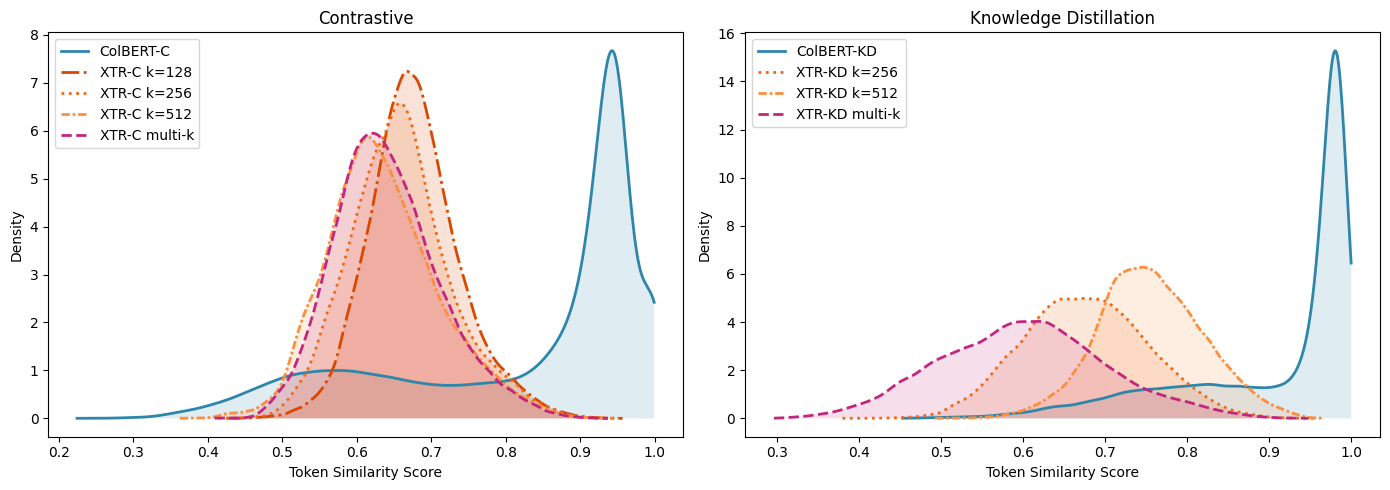

In [192]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

sys.path.insert(0, os.path.join(os.getcwd(), 'scripts'))
from plot_style import get_style

SCORES_DIR = 'outputs/score_distributions/scores'
MAX_KDE_SAMPLES = 100_000
rng = np.random.default_rng(0)

CONTRASTIVE_MODELS = [
    ('mb_colbert_contrastive', 'ColBERT-C'),
    ('mb_xtr_contrastive_k128', 'XTR-C k=128'),
    ('mb_xtr_contrastive_k256', 'XTR-C k=256'),
    ('mb_xtr_contrastive_k512', 'XTR-C k=512'),
    ('mb_xtr_contrastive_multik', 'XTR-C multi-k'),
]

KD_MODELS = [
    ('mb_colbert_kd', 'ColBERT-KD'),
    ('mb_xtr_kd_k256', 'XTR-KD k=256'),
    ('mb_xtr_kd_k512', 'XTR-KD k=512'),
    ('mb_xtr_kd_multik', 'XTR-KD multi-k'),
]

def plot_score_dist(ax, model_list):
    for name, label in model_list:
        path = os.path.join(SCORES_DIR, f'{name}.npy')
        if not os.path.exists(path):
            print(f'  MISSING: {path}')
            continue
        scores = np.load(path)
        scores = scores[np.isfinite(scores)]
        if len(scores) > MAX_KDE_SAMPLES:
            scores = rng.choice(scores, size=MAX_KDE_SAMPLES, replace=False)
        kde = gaussian_kde(scores, bw_method='scott')
        xs = np.linspace(float(scores.min()), float(scores.max()), 500)
        ys = kde(xs)
        style = get_style(name)
        color = ax.plot(xs, ys, label=label, linewidth=2, **style)[0].get_color()
        ax.fill_between(xs, ys, facecolor=color, alpha=0.15)
    ax.set_xlabel('Token Similarity Score')
    ax.set_ylabel('Density')
    ax.legend()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
plot_score_dist(ax1, CONTRASTIVE_MODELS)
ax1.set_title('Contrastive')
plot_score_dist(ax2, KD_MODELS)
ax2.set_title('Knowledge Distillation')
fig.tight_layout()
plt.show()

/scratch/jobs/rjha/224193/ipykernel_397009/2698095837.py:102: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f'{abs(y):.1f}' for y in yticks])


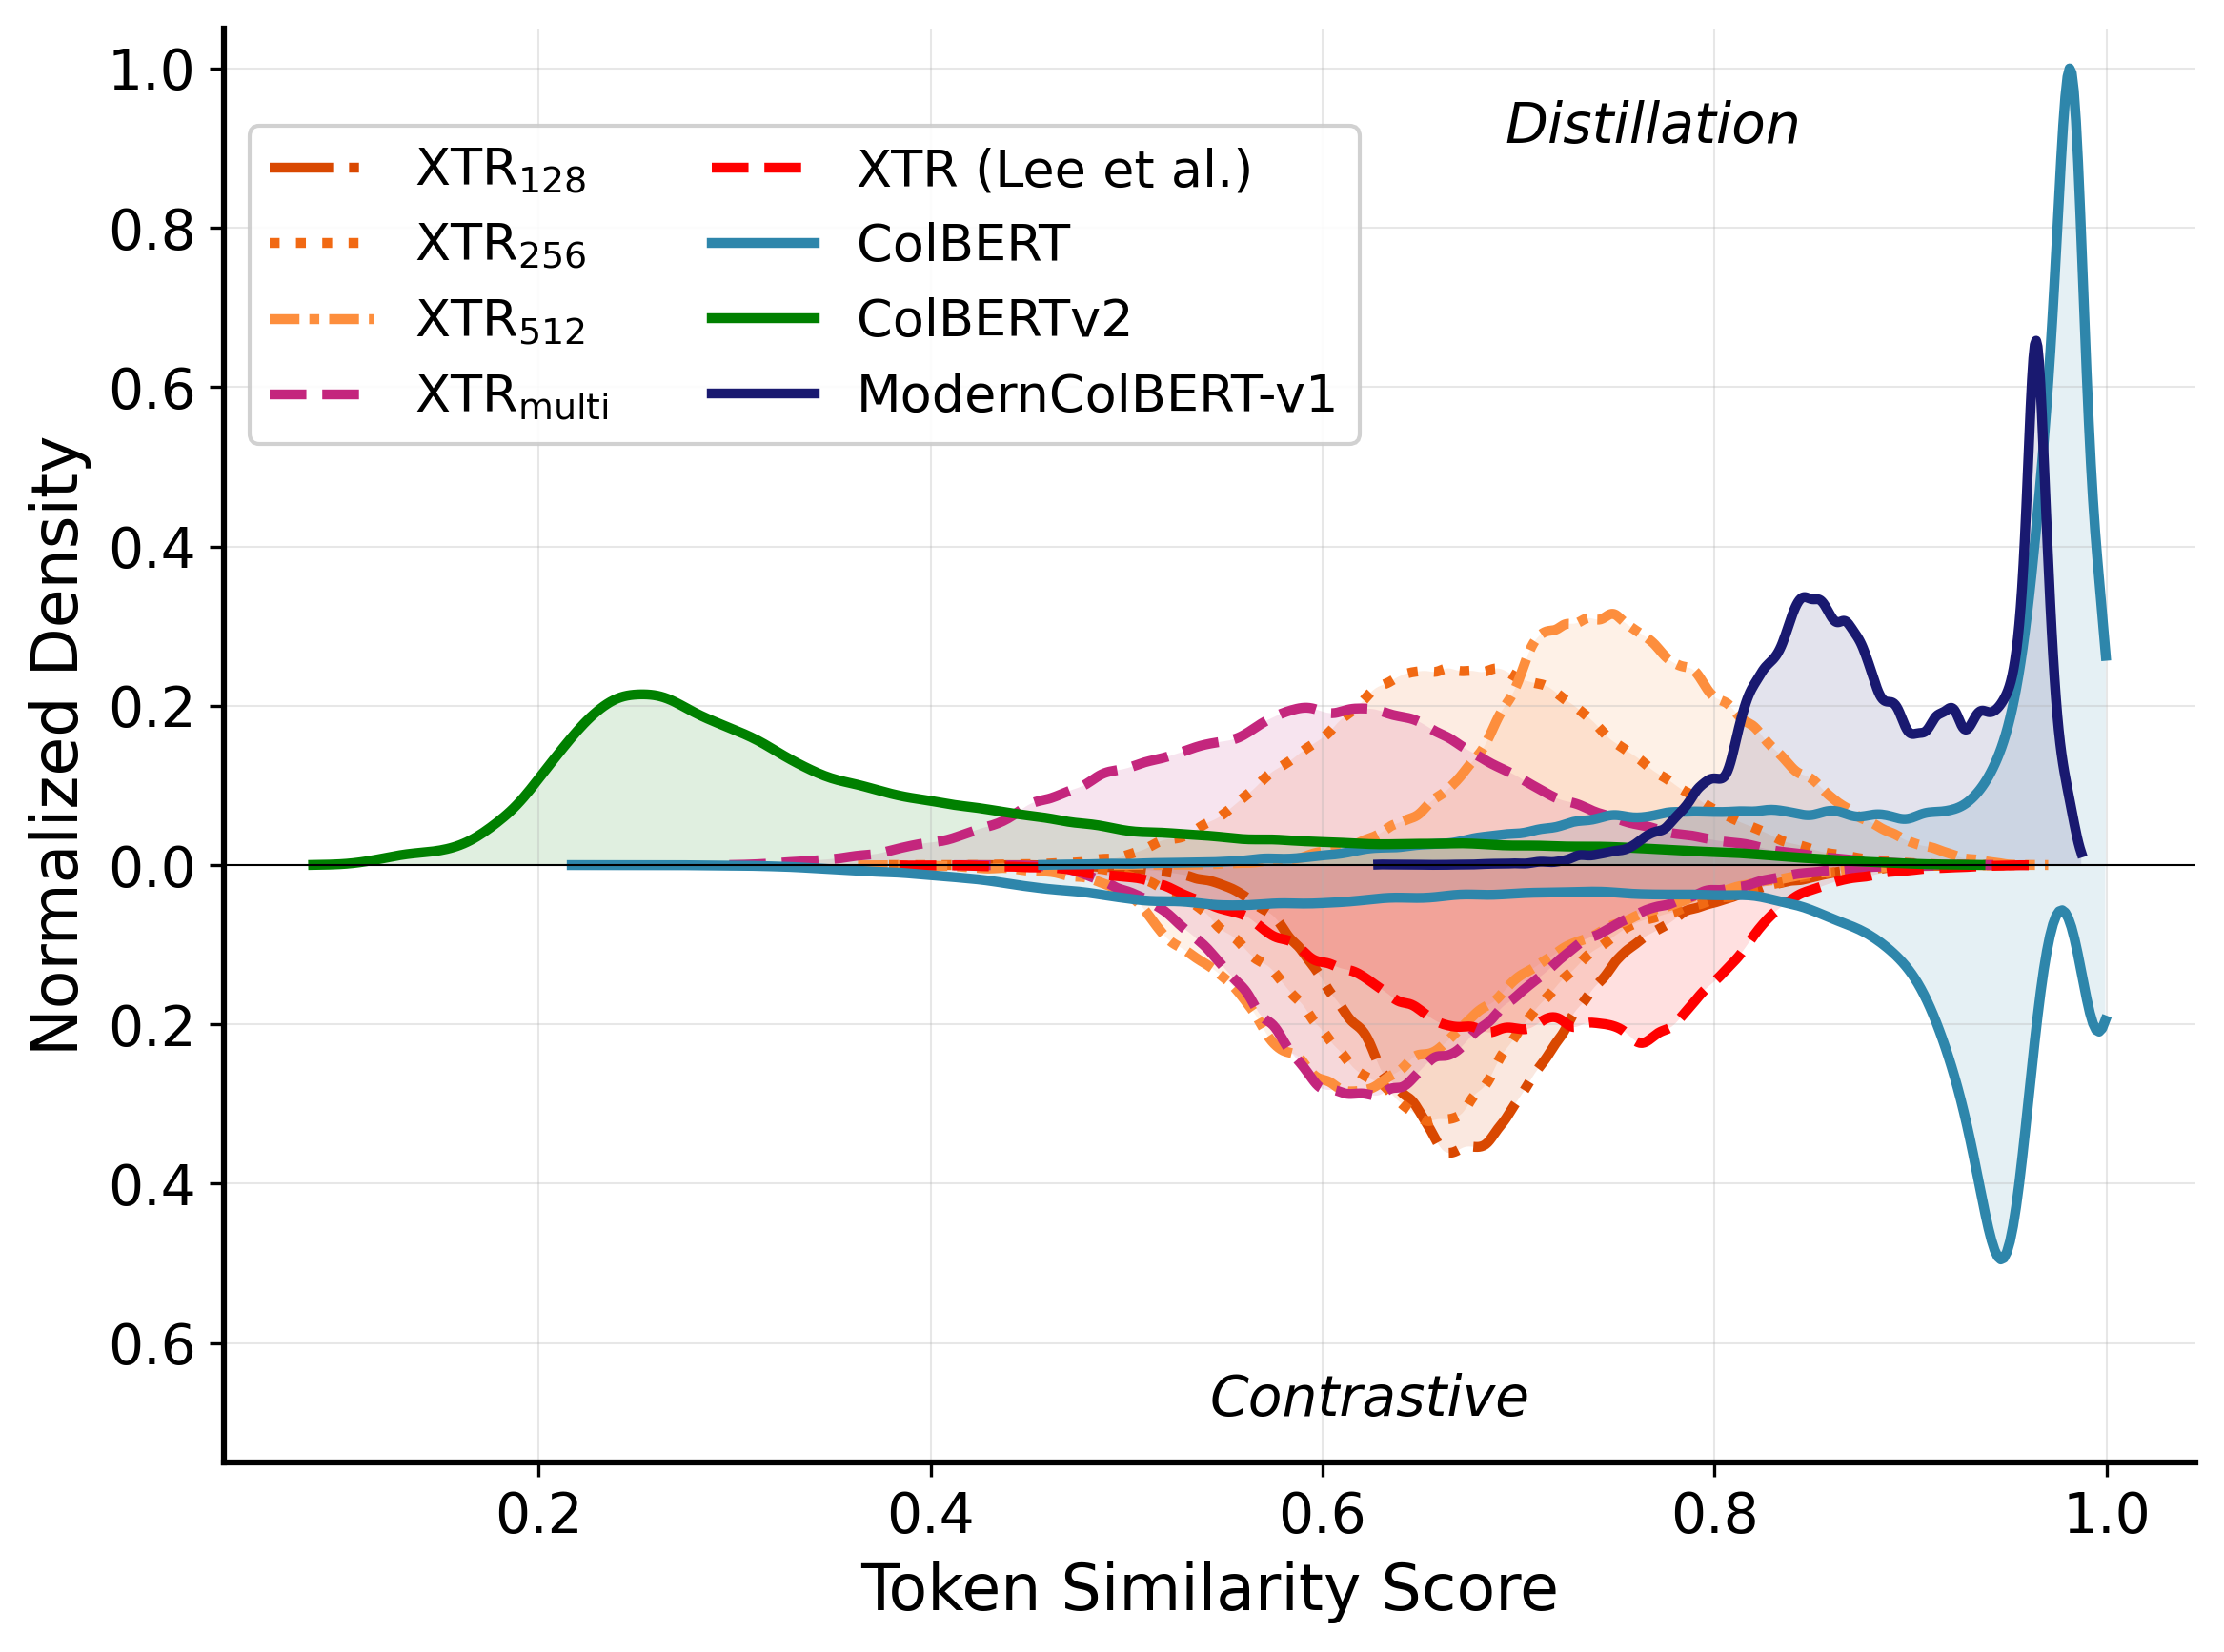

In [206]:
# Mirrored KDE: distillation up, contrastive down, shared x-axis
from plot_style import get_style, MODEL_STYLE

# Set plot style for papers
plt.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.titlesize': 18,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 13,
    'lines.linewidth': 2.5,
    'axes.linewidth': 1.5,
    'grid.linewidth': 0.8,
})

# Models ordered: ColBERT, increasing k (128, 256, 512), multi
# Hardcoded colors for the first three models
HARDCODED_STYLES = {
    'google_xtr': {'color': 'red', 'linestyle': 'dashed'},
    'colbert': {'color': 'green'},
    'gte_moderncolbert_v1': {'color': 'midnightblue'},
}

# Paired models: (contrastive, distillation)
PAIRED = {
    r'XTR$_{128}$': ('mb_xtr_contrastive_k128', None),
    r'XTR$_{256}$': ('mb_xtr_contrastive_k256', 'mb_xtr_kd_k256'),
    r'XTR$_{512}$': ('mb_xtr_contrastive_k512', 'mb_xtr_kd_k512'),
    r'XTR$_{\mathrm{multi}}$': ('mb_xtr_contrastive_multik', 'mb_xtr_kd_multik'),
    r'XTR (Lee et al.)': ('google_xtr', None),
    'ColBERT': ('mb_colbert_contrastive', 'mb_colbert_kd'),
    'ColBERTv2' : (None, 'colbert'),
    'ModernColBERT-v1' : (None, 'gte_moderncolbert_v1'),
}

fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

# Compute max density for normalization
max_density = 0.0

# First pass: compute all KDEs and find max density
all_kdes = {}
for label, (c_name, kd_name) in PAIRED.items():
    for name in [c_name, kd_name]:
        if name is None:
            continue
        path = os.path.join(SCORES_DIR, f'{name}.npy')
        if not os.path.exists(path):
            print(f'  MISSING: {path}')
            continue
        scores = np.load(path)
        scores = scores[np.isfinite(scores)]
        if len(scores) > MAX_KDE_SAMPLES:
            scores = rng.choice(scores, size=MAX_KDE_SAMPLES, replace=False)
        kde = gaussian_kde(scores, bw_method=0.05)
        xs = np.linspace(float(scores.min()), float(scores.max()), 500)
        ys = kde(xs)
        all_kdes[name] = (xs, ys)
        max_density = max(max_density, ys.max())

# Add light grid behind
ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5, zorder=0)

# Second pass: plot with normalized densities (flipped: kd=1, contrastive=-1)
for label, (c_name, kd_name) in PAIRED.items():
    # Use contrastive name for style if available, otherwise use kd name
    style_name = c_name if c_name is not None else kd_name
    
    # Check if we should use hardcoded color
    if style_name in HARDCODED_COLORS:
        style = HARDCODED_STYLES[style_name]
    else:
        style = get_style(style_name)
    
    for name, sign in [(kd_name, 1), (c_name, -1)]:
        if name is None or name not in all_kdes:
            continue
        xs, ys = all_kdes[name]
        ys_norm = (ys / max_density) * sign
        # Only label once (on the distillation/upper side if available, otherwise on contrastive side)
        should_label = (sign == 1 and kd_name is not None) or (sign == -1 and kd_name is None)
        ax.plot(xs, ys_norm, label=label if should_label else None,
                linewidth=2.5, zorder=2, **style)
        ax.fill_between(xs, ys_norm, facecolor=style.get('color', 'C0'), alpha=0.12, zorder=1)

ax.axhline(0, color='black', linewidth=0.5, zorder=3)
ax.set_xlabel('Token Similarity Score')
ax.set_ylabel('Normalized Density')

# Label the two halves
ax.text(0.65, 0.95, 'Distillation', transform=ax.transAxes,
        va='top', ha='left', fontsize=14, fontstyle='oblique')
ax.text(0.5, 0.025, 'Contrastive', transform=ax.transAxes,
        va='bottom', ha='left', fontsize=14, fontstyle='oblique')

# Set symmetric y-limits so both halves have equal height
ax.set_ylim(-0.75, 1.05)

# Hide negative tick labels on y-axis (just show magnitude)
yticks = ax.get_yticks()
ax.set_yticklabels([f'{abs(y):.1f}' for y in yticks])

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(loc='upper left', bbox_to_anchor=(0, 0.95), framealpha=0.9, ncols=2)
plt.tight_layout()
plt.savefig("outputs/score_distributions/score_dist_all_mirrorplot.pdf")
plt.show()

## Token Retrieval Analysis: P(Gold | rank) and P(Lexical | rank)

In [ ]:
import gzip
import ir_datasets

DATASET_ID = "beir/nfcorpus/test"
# DATASET_ID = "beir/trec-covid"
RAW_DIR = f"outputs/token_retrieval_analysis/{DATASET_ID.replace('/', '_')}/raw"

MODELS = [
    ("mb_colbert_kd", "ColBERT-KD"),
    ("mb_xtr_kd_k256", "XTR-KD k=256"),
    ("mb_xtr_kd_k512", "XTR-KD k=512"),
    ("mb_xtr_kd_multik", "XTR-KD multi-k"),
    ("mb_colbert_contrastive", "ColBERT-C"),
    ("mb_xtr_contrastive_k128", "XTR-C k=128"),
    ("mb_xtr_contrastive_k256", "XTR-C k=256"),
    ("mb_xtr_contrastive_k512", "XTR-C k=512"),
    ("mb_xtr_contrastive_multik", "XTR-C multi-k"),
]

# Load qrels
dataset = ir_datasets.load(DATASET_ID)
gold_pairs = set()
for qrel in dataset.qrels_iter():
    if int(qrel.relevance) > 0:
        gold_pairs.add((qrel.query_id, qrel.doc_id))
print(f"Loaded {len(gold_pairs)} gold (qid, doc_id) pairs")

# Load and annotate each model's raw TSV
data_by_label = {}
for name, label in MODELS:
    path = os.path.join(RAW_DIR, f"{name}.tsv.gz")
    if not os.path.exists(path):
        print(f"  MISSING: {path}")
        continue
    df = pd.read_csv(path, sep="\t", dtype={"qid": str, "doc_id": str})
    df["is_lexical"] = df["query_token_id"] == df["doc_token_id"]
    df["is_gold"] = [
        (row.qid, row.doc_id) in gold_pairs for row in df.itertuples()
    ]
    print(f"  {label}: {len(df):,} rows, P(Gold)={df['is_gold'].mean():.4f}, P(Lexical)={df['is_lexical'].mean():.4f}")
    data_by_label[label] = df

In [ ]:
from plot_style import get_style

label_styles = {label: get_style(name) for name, label in MODELS}

# Build a stable mapping so missing model files do not shift zip alignment
data_by_name = {name: data_by_label[label] for name, label in MODELS if label in data_by_label}

# Separate models by training stage
kd_models = {
    label: data_by_name[name]
    for name, label in MODELS
    if 'kd' in name and 'contrastive' not in name and name in data_by_name
}
contrastive_models = {
    label: data_by_name[name]
    for name, label in MODELS
    if 'contrastive' in name and name in data_by_name
}

# --- Combined 2x2 superplot ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

XLIM = 250
EMA_ALPHA = 0.5  # Set to None to disable smoothing, or a value like 0.1 for smoothing

def apply_ema(series, alpha):
    """Apply exponential moving average smoothing if alpha is not None."""
    if alpha is None:
        return series
    return series.ewm(alpha=alpha, adjust=False).mean()

# Row 0: P(Gold | rank)
# Col 0: Distillation (KD)
for label, df in kd_models.items():
    p_gold = df.groupby("rank")["is_gold"].mean()
    p_gold = apply_ema(p_gold, EMA_ALPHA)
    kw = label_styles.get(label, {})
    axes[0, 0].plot(p_gold.index, p_gold.values, label=label, linewidth=2, **kw)
axes[0, 0].set_ylabel("P(Gold | Token@k)")
axes[0, 0].set_title("Distillation")
axes[0, 0].spines['top'].set_visible(False)
axes[0, 0].spines['right'].set_visible(False)
axes[0, 0].spines['bottom'].set_visible(False)
axes[0, 0].tick_params(bottom=False, labelbottom=False)
axes[0, 0].grid(True, color='grey', alpha=0.3, linestyle='-', linewidth=0.5)

# Col 1: Contrastive
for label, df in contrastive_models.items():
    p_gold = df.groupby("rank")["is_gold"].mean()
    p_gold = apply_ema(p_gold, EMA_ALPHA)
    kw = label_styles.get(label, {})
    axes[0, 1].plot(p_gold.index, p_gold.values, label=label, linewidth=2, **kw)
axes[0, 1].set_title("Contrastive")
axes[0, 1].spines['top'].set_visible(False)
axes[0, 1].spines['right'].set_visible(False)
axes[0, 1].spines['bottom'].set_visible(False)
axes[0, 1].spines['left'].set_visible(False)
axes[0, 1].tick_params(bottom=False, labelbottom=False, left=False, labelleft=False)
axes[0, 1].grid(True, color='grey', alpha=0.3, linestyle='-', linewidth=0.5)

# Row 1: P(Lexical | rank)
# Col 0: Distillation (KD)
for label, df in kd_models.items():
    p_lexical = df.groupby("rank")["is_lexical"].mean()
    p_lexical = apply_ema(p_lexical, EMA_ALPHA)
    kw = label_styles.get(label, {})
    axes[1, 0].plot(p_lexical.index, p_lexical.values, label=label, linewidth=2, **kw)
axes[1, 0].set_xlabel("Rank")
axes[1, 0].set_ylabel("P(Lexical | Token@k)")
axes[1, 0].spines['top'].set_visible(False)
axes[1, 0].spines['right'].set_visible(False)
axes[1, 0].grid(True, color='grey', alpha=0.3, linestyle='-', linewidth=0.5)

# Col 1: Contrastive
for label, df in contrastive_models.items():
    p_lexical = df.groupby("rank")["is_lexical"].mean()
    p_lexical = apply_ema(p_lexical, EMA_ALPHA)
    kw = label_styles.get(label, {})
    axes[1, 1].plot(p_lexical.index, p_lexical.values, label=label, linewidth=2, **kw)
axes[1, 1].set_xlabel("Rank")
axes[1, 1].spines['top'].set_visible(False)
axes[1, 1].spines['right'].set_visible(False)
axes[1, 1].spines['left'].set_visible(False)
axes[1, 1].tick_params(left=False, labelleft=False)
axes[1, 1].grid(True, color='grey', alpha=0.3, linestyle='-', linewidth=0.5)

# Set x-axis limits to 500 for all subplots
for ax in axes.flat:
    ax.set_xlim(0, XLIM)

# Share y-axis limits for same P
y0_min = min(axes[0, 0].get_ylim()[0], axes[0, 1].get_ylim()[0])
y0_max = max(axes[0, 0].get_ylim()[1], axes[0, 1].get_ylim()[1])
axes[0, 0].set_ylim(y0_min, y0_max)
axes[0, 1].set_ylim(y0_min, y0_max)

y1_min = min(axes[1, 0].get_ylim()[0], axes[1, 1].get_ylim()[0])
y1_max = max(axes[1, 0].get_ylim()[1], axes[1, 1].get_ylim()[1])
axes[1, 0].set_ylim(y1_min, y1_max)
axes[1, 1].set_ylim(y1_min, y1_max)

# Add legend to the figure (not individual plots) - only from KD models to avoid duplicates
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0), ncol=5)

fig.tight_layout()
plt.show()

In [ ]:
from plot_style import get_style

label_styles = {label: get_style(name) for name, label in MODELS}
# Remove linestyle from all label_styles
label_styles = {k: {k2: v2 for k2, v2 in v.items() if k2 != 'linestyle'} for k, v in label_styles.items()}

# Build a stable mapping so missing model files do not shift zip alignment
data_by_name = {name: data_by_label[label] for name, label in MODELS if label in data_by_label}

# Separate models by training stage
kd_models = {
    label: data_by_name[name]
    for name, label in MODELS
    if 'kd' in name and 'contrastive' not in name and name in data_by_name
}
contrastive_models = {
    label: data_by_name[name]
    for name, label in MODELS
    if 'contrastive' in name and name in data_by_name
}

# --- 1x4 layout: [P(Gold) Contrastive, P(Gold) KD, P(Lexical) Contrastive, P(Lexical) KD] ---
fig, axes = plt.subplots(1, 4, figsize=(12, 4), dpi=300)

XLIM = 100
EMA_ALPHA = 0.75  # Set to None to disable smoothing, or a value like 0.1 for smoothing
TRAIN_LABEL_COORDS = (0.1, 0.93)
TRAIN_LABEL_FONT_SIZE = 12

def apply_ema(series, alpha):
    """Apply exponential moving average smoothing if alpha is not None."""
    if alpha is None:
        return series
    return series.ewm(alpha=alpha, adjust=False).mean()

# Col 0: P(Gold | rank) - Contrastive
for label, df in contrastive_models.items():
    p_gold = df.groupby("rank")["is_gold"].mean()
    p_gold = apply_ema(p_gold, EMA_ALPHA)
    kw = label_styles.get(label, {})
    axes[0].plot(p_gold.index, p_gold.values, label=label, linewidth=2, **kw)
axes[0].set_xlabel("Rank", loc='right')
axes[0].set_ylabel("P(Gold | Token@k)")
axes[0].text(*TRAIN_LABEL_COORDS, 'Contrastive', transform=axes[0].transAxes, 
             ha='left', va='center', fontsize=TRAIN_LABEL_FONT_SIZE, style='italic', color='gray')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].grid(True, color='grey', alpha=0.3, linestyle='-', linewidth=0.5)

# Col 1: P(Gold | rank) - Distillation (KD)
for label, df in kd_models.items():
    p_gold = df.groupby("rank")["is_gold"].mean()
    p_gold = apply_ema(p_gold, EMA_ALPHA)
    kw = label_styles.get(label, {})
    axes[1].plot(p_gold.index, p_gold.values, label=label, linewidth=2, **kw)
axes[1].text(*TRAIN_LABEL_COORDS, 'Distillation', transform=axes[1].transAxes, 
             ha='left', va='center', fontsize=TRAIN_LABEL_FONT_SIZE, style='italic', color='gray')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].spines['left'].set_visible(False)
axes[1].tick_params(left=False, labelleft=False)
axes[1].grid(True, color='grey', alpha=0.3, linestyle='-', linewidth=0.5)

# Col 2: P(Lexical | rank) - Contrastive
for label, df in contrastive_models.items():
    p_lexical = df.groupby("rank")["is_lexical"].mean()
    p_lexical = apply_ema(p_lexical, EMA_ALPHA)
    kw = label_styles.get(label, {})
    axes[2].plot(p_lexical.index, p_lexical.values, label=label, linewidth=2, **kw)
axes[2].set_xlabel("Rank", loc='right')
axes[2].set_ylabel("P(Lexical | Token@k)")
axes[2].text(*TRAIN_LABEL_COORDS, 'Contrastive', transform=axes[2].transAxes, 
             ha='left', va='center', fontsize=TRAIN_LABEL_FONT_SIZE, style='italic', color='gray')
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)
axes[2].grid(True, color='grey', alpha=0.3, linestyle='-', linewidth=0.5)

# Col 3: P(Lexical | rank) - Distillation (KD)
for label, df in kd_models.items():
    p_lexical = df.groupby("rank")["is_lexical"].mean()
    p_lexical = apply_ema(p_lexical, EMA_ALPHA)
    kw = label_styles.get(label, {})
    axes[3].plot(p_lexical.index, p_lexical.values, label=label, linewidth=2, **kw)
axes[3].text(*TRAIN_LABEL_COORDS, 'Distillation', transform=axes[3].transAxes, 
             ha='left', va='center', fontsize=TRAIN_LABEL_FONT_SIZE, style='italic', color='gray')
axes[3].spines['top'].set_visible(False)
axes[3].spines['right'].set_visible(False)
axes[3].spines['left'].set_visible(False)
axes[3].tick_params(left=False, labelleft=False)
axes[3].grid(True, color='grey', alpha=0.3, linestyle='-', linewidth=0.5)

# Set x-axis limits to 250 for all subplots
for ax in axes:
    ax.set_xlim(0, XLIM)

# Share y-axis limits for P(Gold) plots
y0_min = min(axes[0].get_ylim()[0], axes[1].get_ylim()[0])
y0_max = max(axes[0].get_ylim()[1], axes[1].get_ylim()[1])
axes[0].set_ylim(y0_min, y0_max)
axes[1].set_ylim(y0_min, y0_max)

# Share y-axis limits for P(Lexical) plots
y1_min = min(axes[2].get_ylim()[0], axes[3].get_ylim()[0])
y1_max = max(axes[2].get_ylim()[1], axes[3].get_ylim()[1])
axes[2].set_ylim(y1_min, y1_max)
axes[3].set_ylim(y1_min, y1_max)

# Add legend to the figure (not individual plots) - only from contrastive models to avoid duplicates
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=4)

# Set spacing: 0 between same P type, some space between P(Gold) and P(Lexical)
fig.subplots_adjust(wspace=0.0, hspace=0.0)
# Add space between axes[1] and axes[2] by adjusting their positions
pos0 = axes[0].get_position()
pos1 = axes[1].get_position()
pos2 = axes[2].get_position()
pos3 = axes[3].get_position()

# Add gap between P(Gold) and P(Lexical) groups and smaller gap betweeen same P type

gap = 0.075
axes[2].set_position([pos2.x0 + gap, pos2.y0, pos2.width, pos2.height])
axes[3].set_position([pos3.x0 + gap, pos3.y0, pos3.width, pos3.height])

# Remove overlapping tick labels (but not the tick itself)

xticks1 = axes[1].get_xticks()
axes[1].set_xticklabels([str(int(t)) if t > 0 else ' ' for t in xticks1])

xticks3 = axes[3].get_xticks()
axes[3].set_xticklabels([str(int(t)) if t > 0 else ' ' for t in xticks3])


# plt.savefig("outputs/token_retrieval_analysis/token_retrieval_analysis.pdf", dpi=300)

In [ ]:
kd_models.keys(), contrastive_models.keys()

In [ ]:
from plot_style import get_style
from matplotlib.patches import ConnectionPatch

# Simplify labels to match score distribution plot format
def simplify_label(label):
    """Convert full labels to simplified format: ColBERT or XTR_{k/multi}"""
    if 'ColBERT' in label:
        return 'ColBERT'
    elif 'multi-k' in label:
        return r'XTR$_{\mathrm{multi}}$'
    elif 'k=' in label:
        # Extract k value (e.g., "XTR-KD k=256" -> "XTR_{256}")
        k_val = label.split('k=')[1].split()[0]
        return f'XTR$_{{{k_val}}}$'
    return label

label_styles = {label: get_style(name) for name, label in MODELS}
# Remove linestyle from all label_styles
label_styles = {k: {k2: v2 for k2, v2 in v.items() if k2 != 'linestyle'} for k, v in label_styles.items()}

# Build a stable mapping so missing model files do not shift zip alignment
data_by_name = {name: data_by_label[label] for name, label in MODELS if label in data_by_label}

# Separate models by training stage
kd_models = {
    label: data_by_name[name]
    for name, label in MODELS
    if 'kd' in name and 'contrastive' not in name and name in data_by_name
}
contrastive_models = {
    label: data_by_name[name]
    for name, label in MODELS
    if 'contrastive' in name and name in data_by_name
}

# Simplify labels for both model groups and label_styles
kd_models = {simplify_label(label): df for label, df in kd_models.items()}
contrastive_models = {simplify_label(label): df for label, df in contrastive_models.items()}
label_styles = {simplify_label(label): style for label, style in label_styles.items()}

# --- 2x2 layout: [[P(Gold) Contrastive, P(Gold) KD], [P(Lexical) Contrastive, P(Lexical) KD]] ---
fig, axes = plt.subplots(2, 2, figsize=(8,6), dpi=300)

XLIM = 300
EMA_ALPHA = 0.75  # Set to None to disable smoothing, or a value like 0.1 for smoothing
TRAIN_LABEL_COORDS = (0.1, 0.93)
TRAIN_LABEL_FONT_SIZE = 12
TRAIN_LABEL_COLOR = 'black'

def apply_ema(series, alpha):
    """Apply exponential moving average smoothing if alpha is not None."""
    if alpha is None:
        return series
    return series.ewm(alpha=alpha, adjust=False).mean()

# Row 0, Col 0: P(Gold | rank) - Contrastive
for label, df in contrastive_models.items():
    p_gold = df.groupby("rank")["is_gold"].mean()
    p_gold = apply_ema(p_gold, EMA_ALPHA)
    kw = label_styles.get(label, {})
    axes[0, 0].plot(p_gold.index, p_gold.values, label=label, linewidth=2, **kw)
axes[0, 0].set_ylabel(r"P(Gold | Token@$k$)")
axes[0, 0].text(*TRAIN_LABEL_COORDS, 'Contrastive', transform=axes[0, 0].transAxes, 
             ha='left', va='center', fontsize=TRAIN_LABEL_FONT_SIZE, style='italic', color=TRAIN_LABEL_COLOR)
axes[0, 0].spines['top'].set_visible(False)
axes[0, 0].spines['right'].set_visible(False)
axes[0, 0].tick_params(bottom=False, labelbottom=False)
axes[0, 0].grid(True, color='grey', alpha=0.3, linestyle='-', linewidth=0.5)

# Row 0, Col 1: P(Gold | rank) - Distillation (KD)
for label, df in kd_models.items():
    p_gold = df.groupby("rank")["is_gold"].mean()
    p_gold = apply_ema(p_gold, EMA_ALPHA)
    kw = label_styles.get(label, {})
    axes[0, 1].plot(p_gold.index, p_gold.values, label=label, linewidth=2, **kw)
axes[0, 1].text(*TRAIN_LABEL_COORDS, 'Distillation', transform=axes[0, 1].transAxes, 
             ha='left', va='center', fontsize=TRAIN_LABEL_FONT_SIZE, style='italic', color=TRAIN_LABEL_COLOR)
axes[0, 1].spines['top'].set_visible(False)
axes[0, 1].spines['right'].set_visible(False)
axes[0, 1].spines['left'].set_visible(False)
axes[0, 1].tick_params(left=False, labelleft=False, bottom=False, labelbottom=False)
axes[0, 1].grid(True, color='grey', alpha=0.3, linestyle='-', linewidth=0.5)

# Row 1, Col 0: P(Lexical | rank) - Contrastive
for label, df in contrastive_models.items():
    p_lexical = df.groupby("rank")["is_lexical"].mean()
    p_lexical = apply_ema(p_lexical, EMA_ALPHA)
    kw = label_styles.get(label, {})
    axes[1, 0].plot(p_lexical.index, p_lexical.values, label=label, linewidth=2, **kw)
axes[1, 0].set_xlabel(r"Token Rank $k$", x=1.0)
axes[1, 0].set_ylabel(r"P(Lexical | Token@$k$)")
axes[1, 0].text(*TRAIN_LABEL_COORDS, 'Contrastive', transform=axes[1, 0].transAxes, 
             ha='left', va='center', fontsize=TRAIN_LABEL_FONT_SIZE, style='italic', color=TRAIN_LABEL_COLOR)
axes[1, 0].spines['top'].set_visible(False)
axes[1, 0].spines['right'].set_visible(False)
axes[1, 0].grid(True, color='grey', alpha=0.3, linestyle='-', linewidth=0.5)

# Row 1, Col 1: P(Lexical | rank) - Distillation (KD)
for label, df in kd_models.items():
    p_lexical = df.groupby("rank")["is_lexical"].mean()
    p_lexical = apply_ema(p_lexical, EMA_ALPHA)
    kw = label_styles.get(label, {})
    axes[1, 1].plot(p_lexical.index, p_lexical.values, label=label, linewidth=2, **kw)
# axes[1, 1].set_xlabel(r"Token Rank $k$", loc='right')
axes[1, 1].text(*TRAIN_LABEL_COORDS, 'Distillation', transform=axes[1, 1].transAxes, 
             ha='left', va='center', fontsize=TRAIN_LABEL_FONT_SIZE, style='italic', color=TRAIN_LABEL_COLOR)
axes[1, 1].spines['top'].set_visible(False)
axes[1, 1].spines['right'].set_visible(False)
axes[1, 1].spines['left'].set_visible(False)
axes[1, 1].tick_params(left=False, labelleft=False)
axes[1, 1].grid(True, color='grey', alpha=0.3, linestyle='-', linewidth=0.5)

# Set x-axis limits to XLIM for all subplots
for ax in axes.flat:
    ax.set_xlim(0, XLIM)

# Share y-axis limits for P(Gold) plots (row 0)
y0_min = min(axes[0, 0].get_ylim()[0], axes[0, 1].get_ylim()[0])
y0_max = max(axes[0, 0].get_ylim()[1], axes[0, 1].get_ylim()[1])
axes[0, 0].set_ylim(y0_min, y0_max)
axes[0, 1].set_ylim(y0_min, y0_max)

# Share y-axis limits for P(Lexical) plots (row 1)
y1_min = min(axes[1, 0].get_ylim()[0], axes[1, 1].get_ylim()[0])
y1_max = max(axes[1, 0].get_ylim()[1], axes[1, 1].get_ylim()[1])
axes[1, 0].set_ylim(y1_min, y1_max)
axes[1, 1].set_ylim(y1_min, y1_max)

# Add legend to the right side of the figure
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(0.9, 0.9), ncol=1)

# Set spacing: 0 between same P type columns, some space between rows
fig.subplots_adjust(wspace=0.0)

# Remove overlapping tick labels on the right column (but not the tick itself)
xticks_01 = axes[0, 1].get_xticks()
axes[0, 1].set_xticklabels([str(int(t)) if t > 0 else ' ' for t in xticks_01])

xticks_11 = axes[1, 1].get_xticks()
axes[1, 1].set_xticklabels([str(int(t)) if t > 0 else ' ' for t in xticks_11])

# One ColBERT label per row with arrows that can cross subplot boundaries.
def get_line_point(ax, label='ColBERT', target_x=40):
    line = next((ln for ln in ax.get_lines() if ln.get_label() == label), None)
    if line is None:
        return None
    x = np.asarray(line.get_xdata())
    y = np.asarray(line.get_ydata())
    if len(x) == 0:
        return None
    idx = int(np.argmin(np.abs(x - target_x)))
    return float(x[idx]), float(y[idx])


def get_text_anchor(text_artist, where):
    """Return anchor point on a fig.text bbox in figure-fraction coordinates."""
    renderer = fig.canvas.get_renderer()
    bb = text_artist.get_window_extent(renderer=renderer)
    if where == 'center_left':
        px, py = bb.x0, (bb.y0 + bb.y1) / 2.0
    elif where == 'center_top':
        px, py = (bb.x0 + bb.x1) / 2.0, bb.y1
    elif where == 'center_bottom':
        px, py = (bb.x0 + bb.x1) / 2.0, bb.y0
    elif where == 'center_right':
        px, py = bb.x1, (bb.y0 + bb.y1) / 2.0
    else:
        raise ValueError(f'Unknown anchor location: {where}')
    return (px / fig.bbox.width, py / fig.bbox.height)



DATASET_TO_LABEL_COORDS = {
    "beir/nfcorpus/test": {
        "top_label_anchor": (0.58, 0.55),
        "bottom_label_anchor": (0.42, 0.3),
        "x_targets": [295, 50, 200, 5],
        "arrow_magnets": ["center_left", "center_top", "center_bottom", "center_right"],
    },
}

# Label centers in figure coordinates.
top_label_anchor = DATASET_TO_LABEL_COORDS[DATASET_ID]["top_label_anchor"]
bottom_label_anchor = DATASET_TO_LABEL_COORDS[DATASET_ID]["bottom_label_anchor"]

top_text = fig.text(*top_label_anchor, 'ColBERT', ha='center', va='center', fontsize=TRAIN_LABEL_FONT_SIZE, color=TRAIN_LABEL_COLOR)
bottom_text = fig.text(*bottom_label_anchor, 'ColBERT', ha='center', va='center', fontsize=TRAIN_LABEL_FONT_SIZE, color=TRAIN_LABEL_COLOR)

# Ensure text bbox is available before measuring anchor points.
fig.canvas.draw()

# Top row starts: center left + center top. Bottom row starts: center bottom + center right.
arrow_specs = list(
    zip(
        [top_text, top_text, bottom_text, bottom_text],
        DATASET_TO_LABEL_COORDS[DATASET_ID]["arrow_magnets"],
        axes.flat,
        DATASET_TO_LABEL_COORDS[DATASET_ID]["x_targets"]
    )
)

for text_artist, start_anchor_name, ax, target_x in arrow_specs:
    start = get_text_anchor(text_artist, start_anchor_name)
    target = get_line_point(ax, label='ColBERT', target_x=target_x)
    if target is None:
        continue
    conn = ConnectionPatch(
        xyA=start,
        coordsA=fig.transFigure,
        xyB=target,
        coordsB=ax.transData,
        arrowstyle='-',
        mutation_scale=10,
        color=TRAIN_LABEL_COLOR,
        lw=1.0,
    )
    conn.set_clip_on(False)
    fig.add_artist(conn)

plt.savefig(f"outputs/token_retrieval_analysis/token_retrieval_analysis_{DATASET_ID.replace('/', '_')}.pdf", dpi=300, bbox_inches='tight')